# 01. BanglaGamba Training Telemetry & Metrics Analysis

This notebook visualizes training metrics, loss progression, learning rate schedule, and validation perplexity from pretraining training logs.

In [1]:
import os
import glob
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

## 1. Training Loss Progression & Metrics Loading

We load training telemetry from `saved/logs/banglagamba_12l/metrics.csv`.

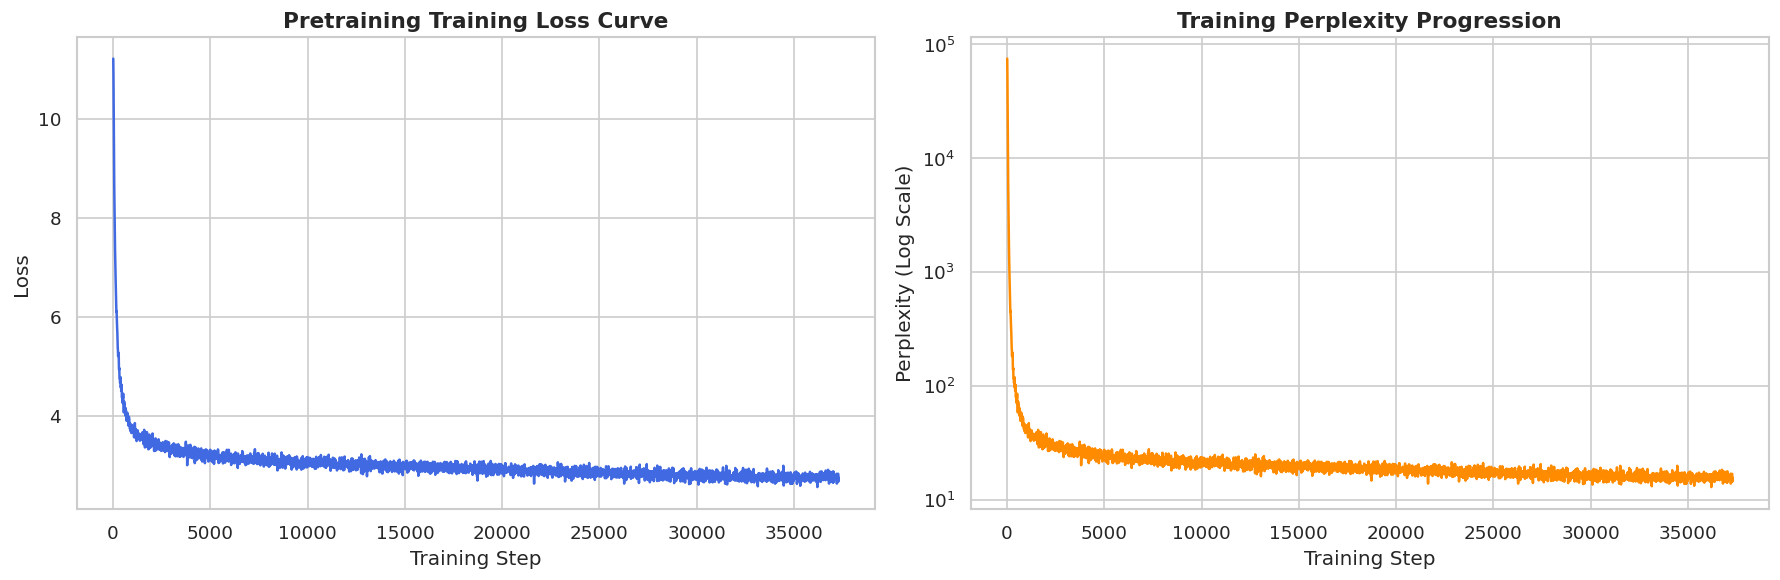

In [2]:
metrics_paths = [
    "../saved/logs/banglagamba_12l/metrics.csv",
    "../saved/logs/metrics.csv",
    "saved/logs/banglagamba_12l/metrics.csv",
    "saved/logs/metrics.csv"
]

metrics_file = None
for p in metrics_paths:
    if os.path.exists(p):
        metrics_file = p
        break

if metrics_file is not None:
    df = pd.read_csv(metrics_file)
else:
    # Fallback to search recursively
    matches = sorted(glob.glob("../saved/logs/**/metrics.csv", recursive=True))
    df = pd.read_csv(matches[-1]) if matches else pd.DataFrame()

if 'step' in df.columns and 'loss' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    sns.lineplot(data=df, x='step', y='loss', color='royalblue', linewidth=1.5, ax=axes[0])
    axes[0].set_title("Pretraining Training Loss Curve", fontsize=13, fontweight='bold')
    axes[0].set_xlabel("Training Step")
    axes[0].set_ylabel("Loss")
    
    if 'perplexity' in df.columns:
        sns.lineplot(data=df, x='step', y='perplexity', color='darkorange', linewidth=1.5, ax=axes[1])
        axes[1].set_title("Training Perplexity Progression", fontsize=13, fontweight='bold')
        axes[1].set_xlabel("Training Step")
        axes[1].set_ylabel("Perplexity (Log Scale)")
        axes[1].set_yscale("log")
    
    plt.tight_layout()
    plt.show()

## 2. Optimizer Learning Rate Schedule

BanglaGamba pretraining uses a hybrid Muon + AdamW optimizer with a linear warmup followed by cosine decay.

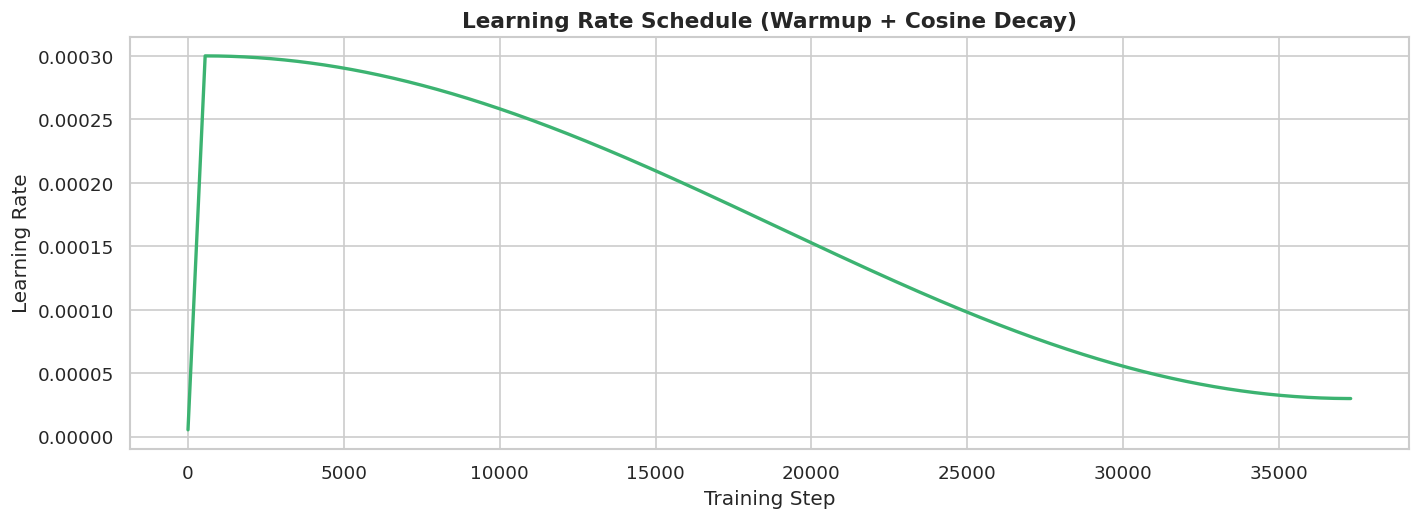

In [3]:
if 'step' in df.columns and 'lr_adamw' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 4.5))
    sns.lineplot(data=df, x='step', y='lr_adamw', color='mediumseagreen', linewidth=2, ax=ax)
    ax.set_title("Learning Rate Schedule (Warmup + Cosine Decay)", fontsize=13, fontweight='bold')
    ax.set_xlabel("Training Step")
    ax.set_ylabel("Learning Rate")
    plt.tight_layout()
    plt.show()

## 3. Validation Evaluation Telemetry Across Domains

Validation metrics logged during pretraining across Bangla, English, and Parallel Translation validation subsets.

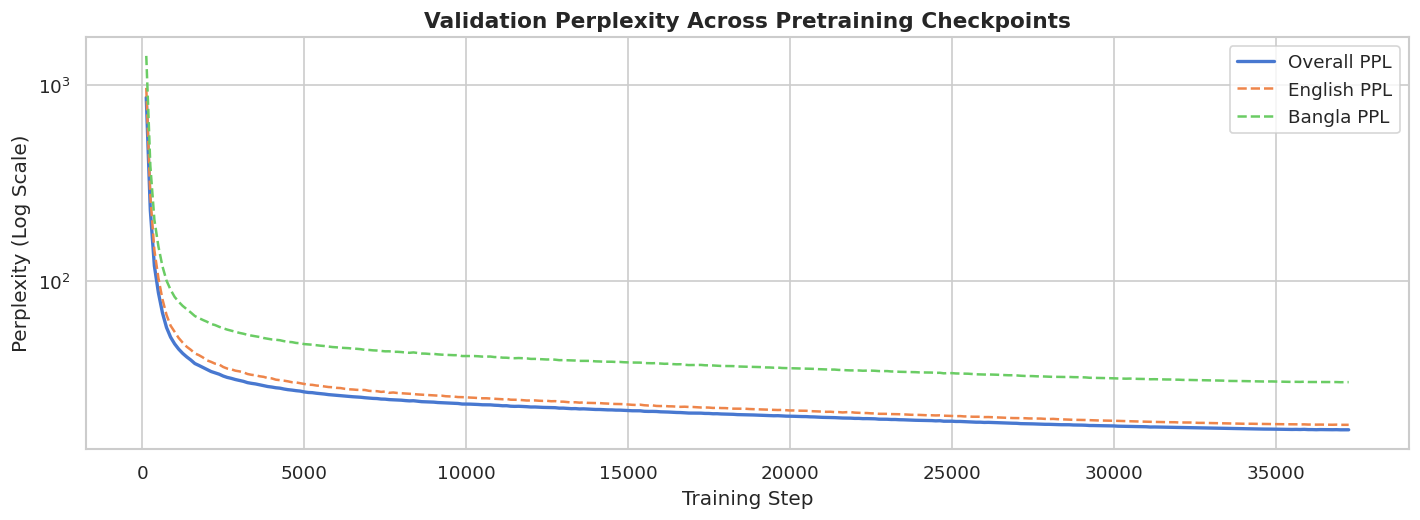

In [4]:
eval_paths = [
    "../saved/logs/banglagamba_12l/eval_metrics.csv",
    "../saved/logs/eval_metrics.csv",
    "saved/logs/banglagamba_12l/eval_metrics.csv",
    "saved/logs/eval_metrics.csv"
]

eval_file = None
for p in eval_paths:
    if os.path.exists(p):
        eval_file = p
        break

if eval_file is not None:
    eval_df = pd.read_csv(eval_file)
else:
    matches = sorted(glob.glob("../saved/logs/**/eval_metrics.csv", recursive=True))
    eval_df = pd.read_csv(matches[-1]) if matches else pd.DataFrame()

if 'step' in eval_df.columns:
    fig, ax = plt.subplots(figsize=(12, 4.5))
    if "val_ppl_overall" in eval_df.columns:
        sns.lineplot(data=eval_df, x="step", y="val_ppl_overall", label="Overall PPL", linewidth=2, ax=ax)
    if "val_ppl_eng" in eval_df.columns:
        sns.lineplot(data=eval_df, x="step", y="val_ppl_eng", label="English PPL", linestyle="--", ax=ax)
    if "val_ppl_bng" in eval_df.columns:
        sns.lineplot(data=eval_df, x="step", y="val_ppl_bng", label="Bangla PPL", linestyle="--", ax=ax)
    
    ax.set_title("Validation Perplexity Across Pretraining Checkpoints", fontsize=13, fontweight="bold")
    ax.set_xlabel("Training Step")
    ax.set_ylabel("Perplexity (Log Scale)")
    ax.set_yscale("log")
    ax.legend()
    plt.tight_layout()
    plt.show()